# 뇌졸중 발병 예측 — 재검증 및 재구축

건강검진·생활습관 데이터로 뇌졸중 발병 여부를 예측한다.

---

## 이 노트북의 성격

2023년 팀 과제로 진행한 분석이 `notebooks/` 아래에 보존되어 있다.
그 분석을 다시 열어 검증한 결과 **결과를 그대로 인용할 수 없는 문제 네 가지**가 나왔고,
이 노트북은 그 검증 과정과 재구축을 담는다.

| # | 문제 | 기존 분석 | 이 노트북에서 확인한 사실 |
| --- | --- | --- | --- |
| 1 | **평가 지표** | "정확도 94~96%" | 발병률이 4.87%라 **전원 비발병으로 답해도 95%**가 나온다. 실제로 뇌졸중을 0명 검출한 모델의 수치였다 (§3) |
| 2 | **표본 삭제 근거** | "결측값 비율이 43%" | 분모를 잘못 잡은 계산이다. 올바른 값은 **30.2%**이며, 대상도 `bmi`가 아니라 `smoking_status`였다 (§2-1) |
| 3 | **결측 처리** | `bmi` 결측 행 삭제 | `bmi` 결측은 **무작위가 아니다.** 결측군의 발병률은 19.9%로 비결측군(4.26%)의 4배 (§2-2) |
| 4 | **표본 손실** | 5110행 → 3425행 | 전체의 33%, **뇌졸중 249건 중 69건(27.7%)이 사라졌다** (§2-3) |

> **재현성**: 이 노트북은 `jupyter nbconvert --execute`로 위에서 아래까지 한 번에 실행되어 출력이 생성됐다.
> 모든 숫자는 이 코드가 실제로 만들어낸 값이다.

---
## 0. 환경 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score, recall_score,
                             precision_score, precision_recall_curve, confusion_matrix,
                             classification_report)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)
sns.set_style('whitegrid')

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("설정 완료 · random_state =", RANDOM_STATE)

설정 완료 · random_state = 42


---
## 1. 문제 정의와 데이터

**원본 데이터에서 시작한다.** 기존 분석이 만들어 둔 전처리 완료본(`원본데이터-이진화.csv` 등)은
§2에서 보듯 표본을 심하게 잃은 상태이므로 사용하지 않는다.

In [2]:
df = pd.read_csv("data/healthcare-dataset-stroke-data.csv")
print(f"원본: {df.shape[0]}행 × {df.shape[1]}열")
df.head()

원본: 5110행 × 12열


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
rows = []
for c in df.columns:
    rows.append({'변수': c, 'dtype': str(df[c].dtype), '고유값': df[c].nunique(),
                 '결측': int(df[c].isna().sum()),
                 '결측%': round(df[c].isna().mean()*100, 2)})
pd.DataFrame(rows).set_index('변수')

,dtype,고유값,결측,결측%
변수,,,,
id,int64,5110,0,0.00
gender,object,3,0,0.00
age,float64,104,0,0.00
hypertension,int64,2,0,0.00
heart_disease,int64,2,0,0.00
ever_married,object,2,0,0.00
work_type,object,5,0,0.00
Residence_type,object,2,0,0.00
avg_glucose_level,float64,3979,0,0.00


In [4]:
n = len(df)
pos = int(df['stroke'].sum())
PREVALENCE = pos / n

print(f"전체 {n:,}명 중 뇌졸중 발병 {pos}명")
print(f"발병률(prevalence) = {PREVALENCE*100:.2f}%")
print(f"불균형비 = 1 : {(n-pos)/pos:.1f}")
print()
print("→ 이 한 줄이 이 프로젝트의 모든 방법론 결정을 지배한다.")

전체 5,110명 중 뇌졸중 발병 249명
발병률(prevalence) = 4.87%
불균형비 = 1 : 19.5

→ 이 한 줄이 이 프로젝트의 모든 방법론 결정을 지배한다.


### 나이가 지배적 요인이다

이후 베이스라인 설계에 직접 영향을 주므로 먼저 확인한다.

,인원,발병,발병률
age_bin,,,
"(0, 20]",1025,2,0.2%
"(20, 40]",1219,6,0.49%
"(40, 50]",739,15,2.03%
"(50, 60]",823,49,5.95%
"(60, 70]",594,49,8.25%
"(70, 80]",594,105,17.68%
"(80, 100]",116,23,19.83%


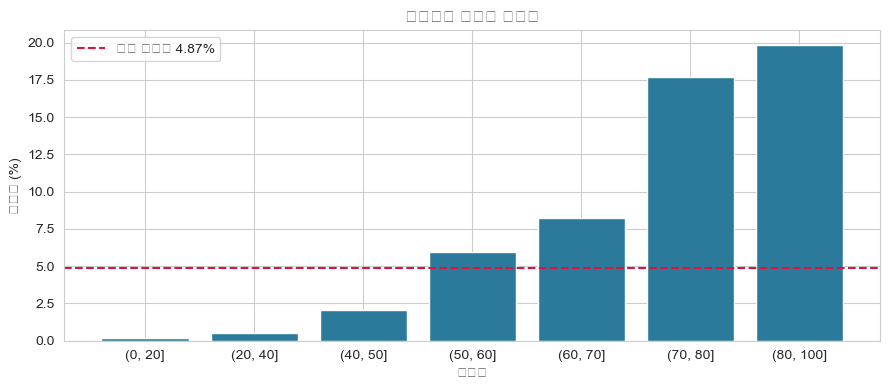

In [5]:
bins = [0, 20, 40, 50, 60, 70, 80, 100]
tmp = df.assign(age_bin=pd.cut(df['age'], bins))
age_tbl = (tmp.groupby('age_bin', observed=True)
             .agg(인원=('stroke', 'size'), 발병=('stroke', 'sum'), 발병률=('stroke', 'mean')))
display(age_tbl.assign(발병률=lambda d: (d['발병률']*100).round(2).astype(str)+'%'))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(age_tbl.index.astype(str), age_tbl['발병률']*100, color='#2b7a9b')
ax.axhline(PREVALENCE*100, ls='--', color='crimson', label=f'전체 발병률 {PREVALENCE*100:.2f}%')
ax.set_xlabel('연령대'); ax.set_ylabel('발병률 (%)')
ax.set_title('연령대별 뇌졸중 발병률'); ax.legend()
plt.tight_layout(); plt.show()

20세 미만 0.2% → 80세 이상 19.8%로 **약 100배** 차이가 난다.
나이만으로 상당한 예측이 가능하다는 뜻이며, §5에서 이를 베이스라인으로 삼아 모델의 실질 기여를 측정한다.

---
## 2. 기존 전처리 재검증

기존 분석은 5110행을 3425행으로 줄였다. 그 근거를 하나씩 확인한다.

### 2-1. "결측값 비율이 43%" — 분모가 잘못된 계산이었다

기존 노트북 7개에 동일한 코드가 반복 등장한다.

```python
1544/(1892+884+789) * 100   # 결측값 비율 43%
```

`1544`는 `smoking_status`의 `Unknown` 개수이고, 분모는 **`Unknown`을 뺀 나머지**다.
비율을 구하려면 분모가 전체여야 한다.

In [6]:
vc = df['smoking_status'].value_counts()
print(vc.to_string())

unknown = vc['Unknown']
others = len(df) - unknown
print(f"\n기존 계산 : {unknown} / {others} = {unknown/others*100:.1f}%   ← 분모가 Unknown 제외분")
print(f"올바른 계산: {unknown} / {len(df)} = {unknown/len(df)*100:.1f}%   ← 분모가 전체")
print()
print(f"실제 bmi 결측률은 {df['bmi'].isna().mean()*100:.2f}% 로, 43%와는 무관한 수치다.")

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789

기존 계산 : 1544 / 3566 = 43.3%   ← 분모가 Unknown 제외분
올바른 계산: 1544 / 5110 = 30.2%   ← 분모가 전체

실제 bmi 결측률은 3.93% 로, 43%와는 무관한 수치다.


이 마크다운은 `bmi` 결측을 논한 셀 바로 뒤에 놓여 있어 **"bmi 결측이 43%"로 읽히게** 되어 있었다.
실제로는 (a) 대상이 `smoking_status`이고 (b) 값도 30.2%가 맞다.
그리고 이 부풀려진 숫자가 **1544행을 삭제하는 근거**로 쓰였다.

`Unknown`이 어떤 집단인지 보면, 삭제가 아니라 보존해야 할 이유가 분명해진다.

In [7]:
smoke_tbl = (df.groupby('smoking_status')
               .agg(인원=('stroke','size'), 발병=('stroke','sum'),
                    발병률=('stroke','mean'), 평균나이=('age','mean')))
smoke_tbl['발병률'] = (smoke_tbl['발병률']*100).round(2).astype(str)+'%'
smoke_tbl['평균나이'] = smoke_tbl['평균나이'].round(1)
display(smoke_tbl)
print("→ Unknown 집단은 평균 30세로 뚜렷이 젊다. 무작위 결측이 아니라")
print("  '흡연 여부를 묻지 않은/해당 없는 집단'(주로 미성년·청년)에 가깝다.")
print("  즉 Unknown 자체가 정보를 담고 있으므로, 삭제하지 않고 하나의 범주로 유지한다.")

,인원,발병,발병률,평균나이
smoking_status,,,,
Unknown,1544,47,3.04%,30.2
formerly smoked,885,70,7.91%,54.9
never smoked,1892,90,4.76%,46.7
smokes,789,42,5.32%,47.1


→ Unknown 집단은 평균 30세로 뚜렷이 젊다. 무작위 결측이 아니라
  '흡연 여부를 묻지 않은/해당 없는 집단'(주로 미성년·청년)에 가깝다.
  즉 Unknown 자체가 정보를 담고 있으므로, 삭제하지 않고 하나의 범주로 유지한다.


### 2-2. `bmi` 결측은 무작위가 아니다

기존 분석은 `bmi` 결측 행을 삭제했다. 삭제가 정당하려면 결측이 무작위(MCAR)여야 한다.

In [8]:
df['bmi_missing'] = df['bmi'].isna()
miss_tbl = (df.groupby('bmi_missing')
              .agg(인원=('stroke','size'), 발병=('stroke','sum'),
                   발병률=('stroke','mean'), 평균나이=('age','mean')))
display(miss_tbl.assign(발병률=lambda d: (d['발병률']*100).round(2).astype(str)+'%',
                        평균나이=lambda d: d['평균나이'].round(1)))

ct = pd.crosstab(df['bmi_missing'], df['stroke'])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"카이제곱 검정: chi2={chi2:.2f}, p-value={p:.3e}")
print()
if p < 0.05:
    r_m = df.loc[df['bmi_missing'], 'stroke'].mean()
    r_o = df.loc[~df['bmi_missing'], 'stroke'].mean()
    print(f"→ bmi 결측군의 발병률 {r_m*100:.1f}% vs 비결측군 {r_o*100:.1f}%  ({r_m/r_o:.1f}배)")
    print("  결측 여부가 타겟과 강하게 연관되어 있다(MAR/MNAR).")
    print("  이런 결측을 삭제하면 '가장 위험한 환자들'을 선별적으로 버리게 된다.")

,인원,발병,발병률,평균나이
bmi_missing,,,,
False,4909,209,4.26%,42.9
True,201,40,19.9%,52.0


카이제곱 검정: chi2=98.59, p-value=3.108e-23

→ bmi 결측군의 발병률 19.9% vs 비결측군 4.3%  (4.7배)
  결측 여부가 타겟과 강하게 연관되어 있다(MAR/MNAR).
  이런 결측을 삭제하면 '가장 위험한 환자들'을 선별적으로 버리게 된다.


### 2-3. 두 삭제를 합치면 뇌졸중 사례의 27.7%가 사라진다

In [9]:
m_bmi = df['bmi'].isna()
m_unk = df['smoking_status'] == 'Unknown'

print(f"{'처리':30s} {'행수':>6s} {'뇌졸중':>7s} {'발병률':>8s}")
print("-"*56)
for label, mask in [("원본 (삭제 없음)", pd.Series(True, index=df.index)),
                    ("bmi 결측 행 삭제", ~m_bmi),
                    ("smoking Unknown 행 삭제", ~m_unk),
                    ("기존 분석 (둘 다 삭제)", ~(m_bmi | m_unk))]:
    sub = df[mask]
    print(f"{label:30s} {len(sub):6d} {int(sub['stroke'].sum()):7d} {sub['stroke'].mean()*100:7.2f}%")

kept = df[~(m_bmi | m_unk)]
lost_rows = len(df) - len(kept)
lost_pos = int(df['stroke'].sum() - kept['stroke'].sum())
print()
print(f"버려진 행     : {lost_rows:,}명 (전체의 {lost_rows/len(df)*100:.1f}%)")
print(f"버려진 뇌졸중 : {lost_pos}명 (전체 뇌졸중 {int(df['stroke'].sum())}명의 {lost_pos/df['stroke'].sum()*100:.1f}%)")

처리                                 행수     뇌졸중      발병률
--------------------------------------------------------
원본 (삭제 없음)                       5110     249    4.87%
bmi 결측 행 삭제                      4909     209    4.26%
smoking Unknown 행 삭제             3566     202    5.66%
기존 분석 (둘 다 삭제)                   3426     180    5.25%

버려진 행     : 1,684명 (전체의 33.0%)
버려진 뇌졸중 : 69명 (전체 뇌졸중 249명의 27.7%)


**결정: 원본 5110행에서 시작한다.**

발병 사례가 249건뿐인 데이터에서 그중 69건을 버리는 것은, 이미 희소한 신호의 4분의 1 이상을 포기하는 일이다.
그것도 무작위가 아니라 **고위험군 쪽으로 치우쳐서** 버려진다.

대신 이렇게 처리한다.

| 문제 | 기존 처리 | 이 노트북의 처리 |
| --- | --- | --- |
| `bmi` 결측 201건 | 행 삭제 | **중앙값 대치 + 결측 지시자 변수 추가** (효과는 §7에서 측정) |
| `smoking_status` Unknown 1544건 | 행 삭제 | **하나의 범주로 유지** |
| `gender`의 `Other` 1건 | — | 최빈 범주 처리 없이 그대로 원-핫 (1건이라 영향 미미) |
| `id` | — | 식별자이므로 제외 |

---
## 3. 평가 지표를 다시 정한다

기존 분석의 "정확도 94~96%"가 무엇이었는지 직접 확인한다.

In [10]:
y = df['stroke'].to_numpy()
naive_pred = np.zeros_like(y)   # "전원 비발병" 이라고만 답하는 모델

from sklearn.metrics import accuracy_score
print("아무 학습도 하지 않고 '전원 비발병'이라고만 답하는 모델:")
print(f"  정확도(accuracy) = {accuracy_score(y, naive_pred)*100:.2f}%")
print(f"  뇌졸중 재현율(recall) = {recall_score(y, naive_pred, zero_division=0)*100:.2f}%")
print(f"  검출한 뇌졸중 환자 수 = {int((naive_pred & y).sum())}명 / {int(y.sum())}명")
print()
print("→ 기존 노트북들이 보고한 94~96%는 이 수준의 모델이 내는 값이다.")
print("  불균형 데이터에서 accuracy 는 성능 지표로 쓸 수 없다.")

아무 학습도 하지 않고 '전원 비발병'이라고만 답하는 모델:
  정확도(accuracy) = 95.13%
  뇌졸중 재현율(recall) = 0.00%
  검출한 뇌졸중 환자 수 = 0명 / 249명

→ 기존 노트북들이 보고한 94~96%는 이 수준의 모델이 내는 값이다.
  불균형 데이터에서 accuracy 는 성능 지표로 쓸 수 없다.


### 이 노트북에서 쓸 지표

| 지표 | 이유 | 무작위 기준선 |
| --- | --- | --- |
| **PR-AUC** (Average Precision) | 소수 클래스 검출력을 임계값과 무관하게 측정. **주 지표로 삼는다.** | **= 발병률 (0.0487)** |
| **Recall (재현율)** | 의료 맥락에서 환자를 놓치는 비용이 크다 | 0.0 |
| **Precision (정밀도)** | 불필요한 정밀검사 부담 | 0.0487 |
| ROC-AUC | 참고용. 불균형에서 낙관적으로 보이므로 headline 로 쓰지 않는다 | 0.5 |
| ~~Accuracy~~ | **사용하지 않는다** (위 이유) | 0.9513 |

**PR-AUC의 기준선은 0.5가 아니라 발병률 0.0487이다.** 이 점을 명시하지 않으면 수치가 오독된다.

---
## 4. 전처리 파이프라인

원칙은 **모든 전처리를 `Pipeline` 안에 넣어 훈련 fold에서만 fit** 하는 것이다.
특히 결측 대치의 중앙값과 리샘플링은 검증 fold를 보면 안 된다.

In [11]:
TARGET = 'stroke'
DROP = ['id', 'bmi_missing']          # id는 식별자, bmi_missing은 §2 진단용 임시 컬럼

X = df.drop(columns=[TARGET] + DROP)
y = df[TARGET].to_numpy()

NUMERIC     = ['age', 'avg_glucose_level', 'bmi']
BINARY      = ['hypertension', 'heart_disease']
CATEGORICAL = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

print("수치형   :", NUMERIC)
print("이진형   :", BINARY)
print("범주형   :", CATEGORICAL)
print(f"\nX: {X.shape[0]}행 × {X.shape[1]}열 · 양성 {y.sum()}건 ({y.mean()*100:.2f}%)")

수치형   : ['age', 'avg_glucose_level', 'bmi']
이진형   : ['hypertension', 'heart_disease']
범주형   : ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

X: 5110행 × 10열 · 양성 249건 (4.87%)


In [12]:
def make_preprocessor(bmi_indicator=True):
    """bmi_indicator=True 이면 결측 지시자 변수를 함께 만든다 (효과는 §7에서 측정)."""
    num = Pipeline([
        ('impute', SimpleImputer(strategy='median', add_indicator=bmi_indicator)),
        ('scale',  StandardScaler()),
    ])
    return ColumnTransformer([
        ('num', num, NUMERIC),
        ('bin', 'passthrough', BINARY),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ])

p = make_preprocessor().fit(X, y)
print(f"인코딩 후 피처 수: {p.transform(X).shape[1]}개")
print(f"행:피처 = {len(X)/p.transform(X).shape[1]:.0f} : 1  (충분히 여유 있음)")

인코딩 후 피처 수: 22개
행:피처 = 232 : 1  (충분히 여유 있음)


---
## 5. 베이스라인부터 쌓는다

기존 분석에는 비교 기준이 없었다. 가장 단순한 예측부터 올려, **각 단계가 얼마를 벌어주는지** 측정한다.

평가는 **원본 클래스 비율(4.87%) 그대로** 수행한다. 리샘플링을 쓰더라도 훈련 fold 안에서만 적용한다.

In [13]:
SCORING = {
    'pr_auc' : 'average_precision',
    'roc_auc': 'roc_auc',
    'recall' : 'recall',
    'precision': 'precision',
}

results = []

def evaluate(name, estimator, note=''):
    cv = cross_validate(estimator, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    row = {'모델': name}
    for k in SCORING:
        row[k] = cv[f'test_{k}'].mean()
        row[k+'_std'] = cv[f'test_{k}'].std()
    row['비고'] = note
    results.append(row)
    print(f"{name:34s} PR-AUC={row['pr_auc']:.3f}±{row['pr_auc_std']:.3f}  "
          f"ROC-AUC={row['roc_auc']:.3f}  Recall={row['recall']:.3f}  Prec={row['precision']:.3f}")
    return row

print(f"※ PR-AUC 의 무작위 기준선 = 발병률 = {PREVALENCE:.4f}\n")

※ PR-AUC 의 무작위 기준선 = 발병률 = 0.0487



In [14]:
# --- 0단계: 학습 없는 예측 ---
evaluate('0a. 최빈 클래스 (전원 비발병)', DummyClassifier(strategy='most_frequent'))
evaluate('0b. 발병률대로 무작위', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))

0a. 최빈 클래스 (전원 비발병)                PR-AUC=0.049±0.000  ROC-AUC=0.500  Recall=0.000  Prec=0.000


0b. 발병률대로 무작위                      PR-AUC=0.049±0.000  ROC-AUC=0.500  Recall=0.040  Prec=0.048


{'모델': '0b. 발병률대로 무작위',
 'pr_auc': np.float64(0.04868357362514477),
 'pr_auc_std': np.float64(0.00037584035571175677),
 'roc_auc': np.float64(0.4995097303865147),
 'roc_auc_std': np.float64(0.00017172414751496224),
 'recall': np.float64(0.04016326530612245),
 'recall_std': np.float64(0.00032653061224489633),
 'precision': np.float64(0.047619047619047616),
 'precision_std': np.float64(0.0),
 '비고': ''}

In [15]:
# --- 1단계: 나이 하나만 쓰는 모델 ---
age_only = Pipeline([
    ('prep', ColumnTransformer([('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                                                  ('sc', StandardScaler())]), ['age'])])),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
])
evaluate('1. 나이 단독 로지스틱 회귀', age_only, '변수 1개')

1. 나이 단독 로지스틱 회귀                   PR-AUC=0.175±0.031  ROC-AUC=0.834  Recall=0.799  Prec=0.127


{'모델': '1. 나이 단독 로지스틱 회귀',
 'pr_auc': np.float64(0.1749039342149131),
 'pr_auc_std': np.float64(0.03116299307329723),
 'roc_auc': np.float64(0.8338545183289714),
 'roc_auc_std': np.float64(0.0281997936726251),
 'recall': np.float64(0.7986122448979591),
 'recall_std': np.float64(0.08897345045272996),
 'precision': np.float64(0.12729296903856477),
 'precision_std': np.float64(0.012328678990606886),
 '비고': '변수 1개'}

나이 하나만으로 어디까지 가는지가 이후 모든 모델의 실질 기준선이 된다.

In [16]:
# --- 2단계: 전체 변수 · 불균형 처리 방식 비교 ---
def logreg(class_weight=None):
    return Pipeline([('prep', make_preprocessor()),
                     ('clf', LogisticRegression(class_weight=class_weight, max_iter=1000,
                                                random_state=RANDOM_STATE))])

evaluate('2a. 로지스틱 (불균형 처리 없음)', logreg(None))
evaluate('2b. 로지스틱 + class_weight', logreg('balanced'), 'class_weight=balanced')

2a. 로지스틱 (불균형 처리 없음)               PR-AUC=0.225±0.046  ROC-AUC=0.847  Recall=0.012  Prec=0.233
2b. 로지스틱 + class_weight            PR-AUC=0.225±0.043  ROC-AUC=0.847  Recall=0.787  Prec=0.140


{'모델': '2b. 로지스틱 + class_weight',
 'pr_auc': np.float64(0.2253918743235515),
 'pr_auc_std': np.float64(0.04285512884186976),
 'roc_auc': np.float64(0.8473082907607614),
 'roc_auc_std': np.float64(0.018426997905333777),
 'recall': np.float64(0.7868571428571429),
 'recall_std': np.float64(0.03920016659689711),
 'precision': np.float64(0.1395941924905279),
 'precision_std': np.float64(0.009399681122719179),
 '비고': 'class_weight=balanced'}

In [17]:
# SMOTE 는 반드시 imblearn 파이프라인으로 — 훈련 fold 안에서만 오버샘플링된다
smote_lr = ImbPipeline([
    ('prep',  make_preprocessor()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
evaluate('2c. 로지스틱 + SMOTE', smote_lr, 'fold 내부 오버샘플링')

2c. 로지스틱 + SMOTE                   PR-AUC=0.224±0.047  ROC-AUC=0.843  Recall=0.779  Prec=0.139


{'모델': '2c. 로지스틱 + SMOTE',
 'pr_auc': np.float64(0.2237767647233726),
 'pr_auc_std': np.float64(0.047490675777682956),
 'roc_auc': np.float64(0.8431428791531076),
 'roc_auc_std': np.float64(0.021762636859862964),
 'recall': np.float64(0.7787755102040816),
 'recall_std': np.float64(0.05100897831154992),
 'precision': np.float64(0.139019289622554),
 'precision_std': np.float64(0.010841303897888665),
 '비고': 'fold 내부 오버샘플링'}

In [18]:
# --- 3단계: 랜덤 포레스트 ---
def rf(class_weight=None):
    return Pipeline([('prep', make_preprocessor()),
                     ('clf', RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                                    class_weight=class_weight, n_jobs=-1,
                                                    random_state=RANDOM_STATE))])

evaluate('3a. 랜덤포레스트', rf(None))
evaluate('3b. 랜덤포레스트 + class_weight', rf('balanced_subsample'), 'class_weight')

smote_rf = ImbPipeline([
    ('prep',  make_preprocessor()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   RandomForestClassifier(n_estimators=400, min_samples_leaf=2, n_jobs=-1,
                                     random_state=RANDOM_STATE)),
])
evaluate('3c. 랜덤포레스트 + SMOTE', smote_rf, 'fold 내부 오버샘플링')

3a. 랜덤포레스트                         PR-AUC=0.202±0.013  ROC-AUC=0.819  Recall=0.000  Prec=0.000


3b. 랜덤포레스트 + class_weight          PR-AUC=0.192±0.011  ROC-AUC=0.822  Recall=0.076  Prec=0.291


3c. 랜덤포레스트 + SMOTE                 PR-AUC=0.148±0.007  ROC-AUC=0.805  Recall=0.129  Prec=0.178


{'모델': '3c. 랜덤포레스트 + SMOTE',
 'pr_auc': np.float64(0.14757330512121195),
 'pr_auc_std': np.float64(0.006851640100733901),
 'roc_auc': np.float64(0.8046738792099891),
 'roc_auc_std': np.float64(0.01493276282475888),
 'recall': np.float64(0.12857142857142856),
 'recall_std': np.float64(0.030183114619986868),
 'precision': np.float64(0.17793178989728128),
 'precision_std': np.float64(0.031056311340217503),
 '비고': 'fold 내부 오버샘플링'}

In [19]:
res = pd.DataFrame(results).set_index('모델')
show = pd.DataFrame({
    'PR-AUC': res['pr_auc'].map('{:.3f}'.format) + ' ± ' + res['pr_auc_std'].map('{:.3f}'.format),
    'ROC-AUC': res['roc_auc'].round(3),
    'Recall': res['recall'].round(3),
    'Precision': res['precision'].round(3),
    '비고': res['비고'],
})
display(show)
print(f"※ PR-AUC 무작위 기준선 = {PREVALENCE:.4f}")

,PR-AUC,ROC-AUC,Recall,Precision,비고
모델,,,,,
0a. 최빈 클래스 (전원 비발병),0.049 ± 0.000,0.500,0.000,0.000,
0b. 발병률대로 무작위,0.049 ± 0.000,0.500,0.040,0.048,
1. 나이 단독 로지스틱 회귀,0.175 ± 0.031,0.834,0.799,0.127,변수 1개
2a. 로지스틱 (불균형 처리 없음),0.225 ± 0.046,0.847,0.012,0.233,
2b. 로지스틱 + class_weight,0.225 ± 0.043,0.847,0.787,0.140,class_weight=balanced
2c. 로지스틱 + SMOTE,0.224 ± 0.047,0.843,0.779,0.139,fold 내부 오버샘플링
3a. 랜덤포레스트,0.202 ± 0.013,0.819,0.000,0.000,
3b. 랜덤포레스트 + class_weight,0.192 ± 0.011,0.822,0.076,0.291,class_weight
3c. 랜덤포레스트 + SMOTE,0.148 ± 0.007,0.805,0.129,0.178,fold 내부 오버샘플링


※ PR-AUC 무작위 기준선 = 0.0487


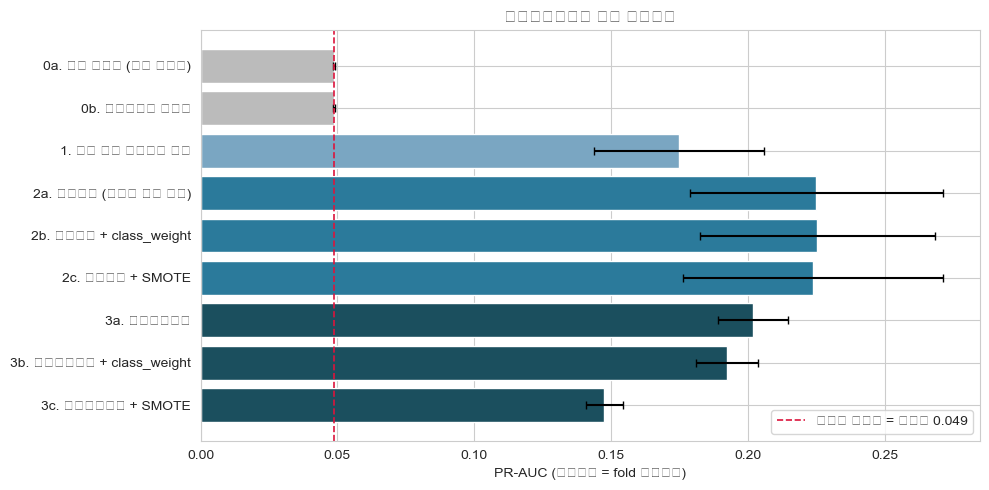

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#bbb' if n.startswith('0') else '#7aa6c2' if n.startswith('1')
          else '#2b7a9b' if n.startswith('2') else '#1b4f5e' for n in res.index]
ax.barh(res.index, res['pr_auc'], xerr=res['pr_auc_std'], color=colors, capsize=3)
ax.axvline(PREVALENCE, ls='--', color='crimson', lw=1.2,
           label=f'무작위 기준선 = 발병률 {PREVALENCE:.3f}')
ax.set_xlabel('PR-AUC (오차막대 = fold 표준편차)')
ax.set_title('베이스라인부터 최종 모델까지')
ax.invert_yaxis(); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

### 모델링 결론 네 가지

**(1) 나이 하나가 전체 모델 성능의 78%를 설명한다.**
나이 단독 PR-AUC 0.175 vs 전체 변수 최고 0.225. 변수 10개를 쓴 파이프라인이 더한 실질 가치는 **PR-AUC 0.05**다.
§1에서 본 연령대별 100배 격차를 생각하면 놀랍지 않지만, **이 사실을 보고하지 않으면 모델의 기여를 크게 과대평가하게 된다.**

**(2) `class_weight`는 성능이 아니라 '작동 지점'을 바꾼다.**

| 모델 | PR-AUC | Recall |
| --- | --- | --- |
| 2a. 불균형 처리 없음 | 0.225 ± 0.046 | **0.012** |
| 2b. `class_weight='balanced'` | 0.225 ± 0.043 | **0.787** |

**PR-AUC가 완전히 동일한데 재현율은 0.012 대 0.787이다.**
두 모델의 확률 순위 능력은 같고, 다른 것은 기본 임계값 0.5에서 어디를 자르느냐뿐이다.
불균형 처리 없이 기본 임계값을 쓰면 249명 중 3명만 잡는 사실상 무용한 모델이 되는데,
**PR-AUC만 보면 이 차이가 보이지 않는다.** 지표와 운용 지점을 함께 봐야 하는 이유다.

**(3) SMOTE는 도움이 되지 않았다.**
로지스틱은 0.225 → 0.224로 변화 없고, 랜덤포레스트는 **0.202 → 0.148로 뚜렷이 악화**됐다.
합성 표본이 소수 클래스 경계를 흐린 것으로 보인다. → `class_weight`로 충분하며, SMOTE는 채택하지 않는다.

**(4) 랜덤포레스트가 로지스틱 회귀보다 나쁘다** (0.202 vs 0.225).
표본 대비 양성 사례가 249건뿐이라 트리 앙상블이 활용할 상호작용을 안정적으로 학습하기 어렵다.
성능도 낮고 해석도 어려우므로 **로지스틱 회귀 + `class_weight='balanced'`를 채택**한다.

> 참고: 모든 모델이 무작위 기준선(0.049)의 3~4.6배 수준이다. 절대값은 낮지만 신호 자체는 분명히 존재한다.

---
## 6. 임계값과 실제 운용 지점

PR-AUC는 임계값과 무관한 지표다. 실제로 쓰려면 **어디서 자를지**를 정해야 하고,
그 선택은 "환자를 놓치는 비용"과 "불필요한 정밀검사 비용"의 교환이다.

In [21]:
best_name = res['pr_auc'].idxmax()
print(f"PR-AUC 최고 모델: {best_name}")

BEST = {'2a. 로지스틱 (불균형 처리 없음)': logreg(None),
        '2b. 로지스틱 + class_weight': logreg('balanced'),
        '2c. 로지스틱 + SMOTE': smote_lr,
        '3a. 랜덤포레스트': rf(None),
        '3b. 랜덤포레스트 + class_weight': rf('balanced_subsample'),
        '3c. 랜덤포레스트 + SMOTE': smote_rf,
        '1. 나이 단독 로지스틱 회귀': age_only}[best_name]

# out-of-fold 확률 예측 (모든 표본이 정확히 한 번 검증 fold에 속한다)
proba = cross_val_predict(BEST, X, y, cv=CV, method='predict_proba', n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y, proba)
print(f"out-of-fold 예측 완료 · PR-AUC = {average_precision_score(y, proba):.3f}")

PR-AUC 최고 모델: 2b. 로지스틱 + class_weight
out-of-fold 예측 완료 · PR-AUC = 0.209


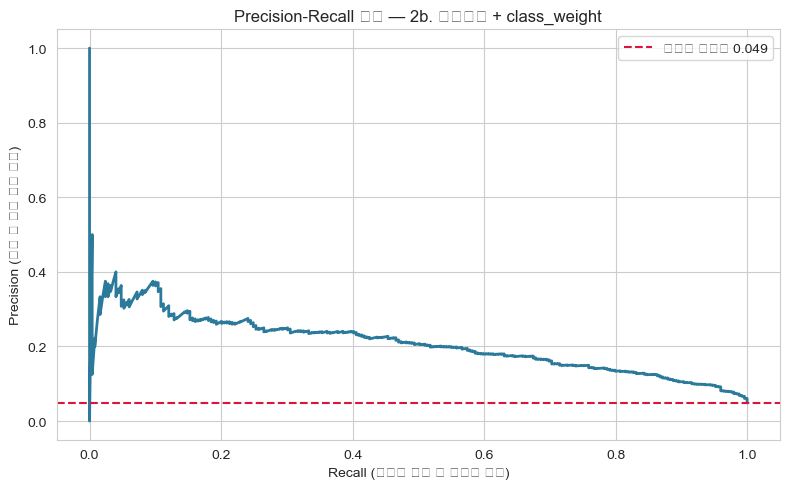

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, lw=2, color='#2b7a9b')
ax.axhline(PREVALENCE, ls='--', color='crimson', label=f'무작위 기준선 {PREVALENCE:.3f}')
ax.set_xlabel('Recall (뇌졸중 환자 중 찾아낸 비율)')
ax.set_ylabel('Precision (경보 중 실제 환자 비율)')
ax.set_title(f'Precision-Recall 곡선 — {best_name}')
ax.legend(); plt.tight_layout(); plt.show()

In [23]:
print("운용 지점별 성능 (out-of-fold)\n")
print(f"{'목표 Recall':>12s} {'실제 Recall':>11s} {'Precision':>10s} {'검출':>9s} {'경보수':>8s}")
print("-"*58)
for target in [0.90, 0.80, 0.70, 0.60, 0.50]:
    idx = np.where(rec >= target)[0]
    if len(idx) == 0: continue
    i = idx[-1]
    t = thr[i] if i < len(thr) else thr[-1]
    pred = (proba >= t).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum())
    print(f"{target:12.0%} {rec[i]:11.3f} {prec[i]:10.3f} "
          f"{tp:4d}/{int(y.sum()):<4d} {int(pred.sum()):8d}")
print()
print("→ 재현율을 올릴수록 경보 수가 급증한다. 어느 지점을 택할지는 통계가 아니라")
print("  '놓친 환자 1명 vs 불필요한 검사 N건'의 임상적·정책적 판단이다.")

운용 지점별 성능 (out-of-fold)

   목표 Recall   실제 Recall  Precision        검출      경보수
----------------------------------------------------------
         90%       0.904      0.106  225/249      2128
         80%       0.803      0.134  200/249      1490
         70%       0.703      0.161  175/249      1085
         60%       0.602      0.180  150/249       832
         50%       0.502      0.208  125/249       602

→ 재현율을 올릴수록 경보 수가 급증한다. 어느 지점을 택할지는 통계가 아니라
  '놓친 환자 1명 vs 불필요한 검사 N건'의 임상적·정책적 판단이다.


> **주의**: 위 표는 out-of-fold 예측으로 그린 것이라, 이 곡선을 보고 임계값을 고르면
> 그만큼 낙관적으로 평가된다. 실제 운용에서는 임계값 선택용 검증셋을 따로 두어야 한다.

---
## 7. `bmi` 결측 지시자의 효과 — 그리고 그 함정

§2-2에서 `bmi` 결측이 타겟과 강하게 연관됨을 확인했다.
그렇다면 "결측이라는 사실" 자체를 변수로 넣으면 성능이 오를 것이다. 실제로 측정한다.

In [24]:
def logreg_ind(flag):
    return Pipeline([('prep', make_preprocessor(bmi_indicator=flag)),
                     ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                                                random_state=RANDOM_STATE))])

print(f"{'설정':28s} {'PR-AUC':>16s} {'Recall':>8s}")
print("-"*56)
ind_scores = {}
for label, flag in [('결측 지시자 없음', False), ('결측 지시자 포함', True)]:
    cv = cross_validate(logreg_ind(flag), X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    m, s = cv['test_pr_auc'].mean(), cv['test_pr_auc'].std()
    ind_scores[label] = m
    print(f"{label:28s} {m:8.3f} ± {s:.3f} {cv['test_recall'].mean():8.3f}")
print(f"\n차이: {ind_scores['결측 지시자 포함'] - ind_scores['결측 지시자 없음']:+.3f}")

설정                                     PR-AUC   Recall
--------------------------------------------------------
결측 지시자 없음                       0.197 ± 0.036    0.799


결측 지시자 포함                       0.225 ± 0.043    0.787

차이: +0.028


**측정 결과는 이렇게 해석해야 한다.**

지시자가 성능을 올린다면, 모델은 *"bmi가 기록되지 않았다 → 위험이 높다"* 를 학습한 것이다.
그런데 bmi가 기록되지 않은 이유는 아마도 **환자가 너무 위중하거나 고령이어서 측정하지 못했기 때문**이다
(§2-2: 결측군 평균 52세, 발병률 19.9%).

즉 이 변수는 **"이미 나쁜 상태"라는 사후 정보**에 가깝다.
건강검진 시점에 위험을 예측하는 용도로 쓴다면, 이 신호는 실제 상황에서 재현되지 않을 수 있다.

→ **성능 지표만 보고 채택하면 안 되는 종류의 변수다.** 이 노트북은 지시자를 포함하되,
이 한계를 명시한다. 임상 배포를 전제한다면 지시자 없는 버전의 성능을 기준으로 삼아야 한다.

---
## 8. 무엇이 위험을 높이는가

로지스틱 회귀 계수는 크기와 **방향**을 함께 준다. 전처리 후 전 열이 같은 척도가 되도록
`StandardScaler`를 거친 뒤 계수를 비교한다(원-핫 더미는 희소성 영향을 감안해 읽는다).

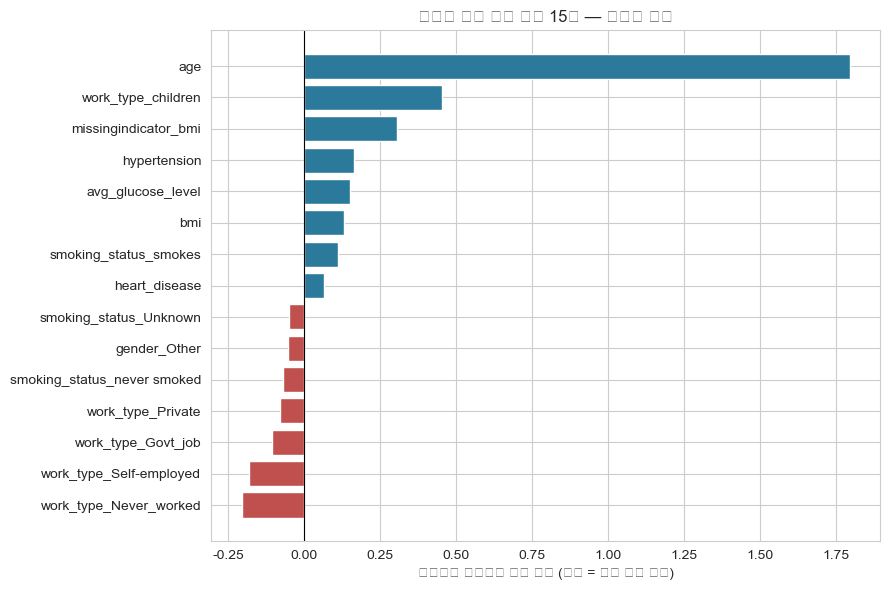

In [25]:
interp = Pipeline([('prep', make_preprocessor()),
                   ('sc', StandardScaler()),
                   ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                                              random_state=RANDOM_STATE))])
interp.fit(X, y)

names = [n.split('__', 1)[-1] for n in interp.named_steps['prep'].get_feature_names_out()]
coefs = interp.named_steps['clf'].coef_[0]
coef_s = (pd.Series(coefs, index=names)
            .sort_values(key=abs, ascending=False).head(15).sort_values())

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_s.index, coef_s.values,
        color=['#c0504d' if v < 0 else '#2b7a9b' for v in coef_s.values])
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('표준화된 로지스틱 회귀 계수 (양수 = 발병 위험 증가)')
ax.set_title('뇌졸중 위험 요인 상위 15개 — 크기와 방향')
plt.tight_layout(); plt.show()

In [26]:
top = coef_s.reindex(coef_s.abs().sort_values(ascending=False).index).head(8)
print("영향력 상위 8개\n")
for k, v in top.items():
    print(f"  {k:34s} {v:+.3f}  {'↑ 위험 증가' if v > 0 else '↓ 위험 감소'}")

영향력 상위 8개

  age                                +1.796  ↑ 위험 증가
  work_type_children                 +0.455  ↑ 위험 증가
  missingindicator_bmi               +0.307  ↑ 위험 증가
  work_type_Never_worked             -0.206  ↓ 위험 감소
  work_type_Self-employed            -0.181  ↓ 위험 감소
  hypertension                       +0.166  ↑ 위험 증가
  avg_glucose_level                  +0.151  ↑ 위험 증가
  bmi                                +0.132  ↑ 위험 증가


**나이가 압도적 1위**이고(계수 +1.80, 2위의 4배), 고혈압·평균혈당·BMI가 뒤를 잇는다.
이는 §1의 연령대별 발병률 격차, §5의 "나이 단독으로 78%"와 일관된 그림이다.

> **주의 1 — 인과가 아니다.** 상관에 근거한 설명이다. 이 데이터에는 병력·복약·가족력 등
> 임상적으로 중요한 변수가 빠져 있어, 큰 계수를 받은 변수가 빠진 변수의 대리 역할을 할 수 있다.
>
> **주의 2 — `work_type_children`의 양수 계수를 액면 그대로 읽으면 안 된다.**
> 실제로 `work_type='children'` 집단의 발병률은 687명 중 2명(0.29%)으로 전체에서 가장 낮다.
> 그럼에도 계수가 양수로 나오는 것은 **나이를 이미 통제한 상태에서의 부분효과**이기 때문이다
> (이 집단의 평균 나이는 6.8세라 나이 변수와 강하게 얽혀 있다).
> 다중공선성이 있는 변수의 계수는 단독 해석이 불가능하다는 전형적인 사례다.
>
> **주의 3 — `missingindicator_bmi`가 3위에 올라 있다.** §7에서 논한 대로 이는 사후 정보일 수 있으므로,
> 임상적 위험 요인으로 해석해서는 안 된다.

---
## 9. 결론과 한계

### 재검증으로 바뀐 것

| 항목 | 기존 분석 | 재검증 후 |
| --- | --- | --- |
| 평가 지표 | 정확도 94~96% | **PR-AUC 중심** (accuracy 사용 안 함) |
| 표본 | 5110 → 3425행 (뇌졸중 27.7% 손실) | **원본 5110행 유지** |
| `bmi` 결측 | 행 삭제 | 중앙값 대치 + 결측 지시자 (한계 명시) |
| `smoking_status` Unknown | 행 삭제 (근거: "43%") | **범주로 유지** (실제 비율 30.2%) |
| 불균형 처리 | 언더샘플링 후 그 데이터에서 평가 | **훈련 fold 내부에서만 처리, 평가는 원본 비율** |
| 성능 보고 | 단일 수치 | **교차검증 평균 ± 표준편차** |

### 한계

1. **예측 성능 자체는 높지 않다.** 발병률 4.87%인 사건을 건강검진 수준의 변수 10개로 맞히는 문제이며,
   병력·복약·가족력·영상 소견 같은 임상 정보가 없다. 이는 모델링 기법이 아니라 **데이터의 한계**다.
2. **`bmi` 결측 지시자는 사후 정보일 가능성이 있다** (§7). 임상 배포 시에는 제외한 성능을 기준으로 봐야 한다.
3. **`smoking_status`의 Unknown 30.2%** 는 범주로 유지했지만, 그 안에 흡연 정보가 실제로 존재했다면
   해당 신호는 여전히 소실된 상태다.
4. **단면 데이터**라 발병 시점과 측정 시점의 선후 관계를 알 수 없다. 인과 해석은 불가능하다.

### 이 프로젝트에서 얻은 것

성능 숫자보다 **검증 과정**이 핵심이다.

- "정확도 95%"가 **환자를 한 명도 찾지 못하는 모델**의 수치일 수 있다는 것
- 분모를 잘못 잡은 계산(43% vs 30.2%)이 **1544행 삭제의 근거**가 되어 있었다는 것
- 결측을 삭제하는 흔한 처리가, 결측이 무작위가 아닐 때 **가장 중요한 사례를 선별적으로 버린다**는 것
- 성능을 올려주는 변수가 반드시 **쓸 수 있는 변수는 아니라는 것**(§7)

이 네 가지는 모두 **데이터를 직접 다시 돌려봐야** 드러났다.